In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from packages import *
from model_3D import *
from tools import *
from mf_module import *
from Loss_function import *

In [4]:
PF_data = np.load('./TD_model/GUO_data/potential_field/PF_td_N3_0.06.npy').astype(np.float32)
nlfff_data = np.load('./TD_model/GUO_data/td_N3_0.06.npy').astype(np.float32)

In [5]:
nlfff_data = adc_shape(nlfff_data)
PF_data = adc_shape(PF_data)
n3 = np.min([nlfff_data.shape[3],PF_data.shape[3]])
nlfff_data = nlfff_data[:,:,:,:n3]
PF_data = PF_data[:,:,:,:n3]

original size:  [107, 171, 77]
modified size:  [96, 160, 64]
original size:  [107, 171, 108]
modified size:  [96, 160, 96]


In [6]:
model = PICNN(PF_data)

In [15]:
# train(self, epoch=100, lr=1e-3, Delta=100, gamma=0.9):
model.L_bc = 1.e6
model.L_div = 1.e1
model.print_epoch=50
model.save_epoch=1000
model._use_mf = True
# model.L_bc = 1.e4
# LR = 1.e-3
LR = 'continue'
step_size = 400
gamma=0.99
model.train(5001, lr=LR, Delta=step_size, gamma=gamma)

Iter 20000, Loss: 1.881e+02, Loss_div: 9.751e+00,Loss_ff: 1.979e+00, Loss_bc: 1.771e-01, wall_time: 6.465e-01 sec, lr: 2.407e-07
Iter 20050, Loss: 1.634e+02, Loss_div: 6.217e+00,Loss_ff: 2.654e+00, Loss_bc: 2.482e-01, wall_time: 1.249e+02 sec, lr: 2.383e-07
Iter 20100, Loss: 1.586e+02, Loss_div: 5.668e+00,Loss_ff: 2.779e+00, Loss_bc: 2.562e-01, wall_time: 2.584e+02 sec, lr: 2.383e-07
Iter 20150, Loss: 1.558e+02, Loss_div: 5.336e+00,Loss_ff: 2.855e+00, Loss_bc: 2.588e-01, wall_time: 3.878e+02 sec, lr: 2.383e-07
Iter 20200, Loss: 1.534e+02, Loss_div: 5.093e+00,Loss_ff: 2.909e+00, Loss_bc: 2.600e-01, wall_time: 5.102e+02 sec, lr: 2.383e-07
Iter 20250, Loss: 1.518e+02, Loss_div: 4.901e+00,Loss_ff: 2.951e+00, Loss_bc: 2.604e-01, wall_time: 6.153e+02 sec, lr: 2.359e-07
Iter 20300, Loss: 1.505e+02, Loss_div: 4.740e+00,Loss_ff: 2.984e+00, Loss_bc: 2.604e-01, wall_time: 6.916e+02 sec, lr: 2.359e-07
Iter 20350, Loss: 1.489e+02, Loss_div: 4.600e+00,Loss_ff: 3.014e+00, Loss_bc: 2.646e-01, wall_tim

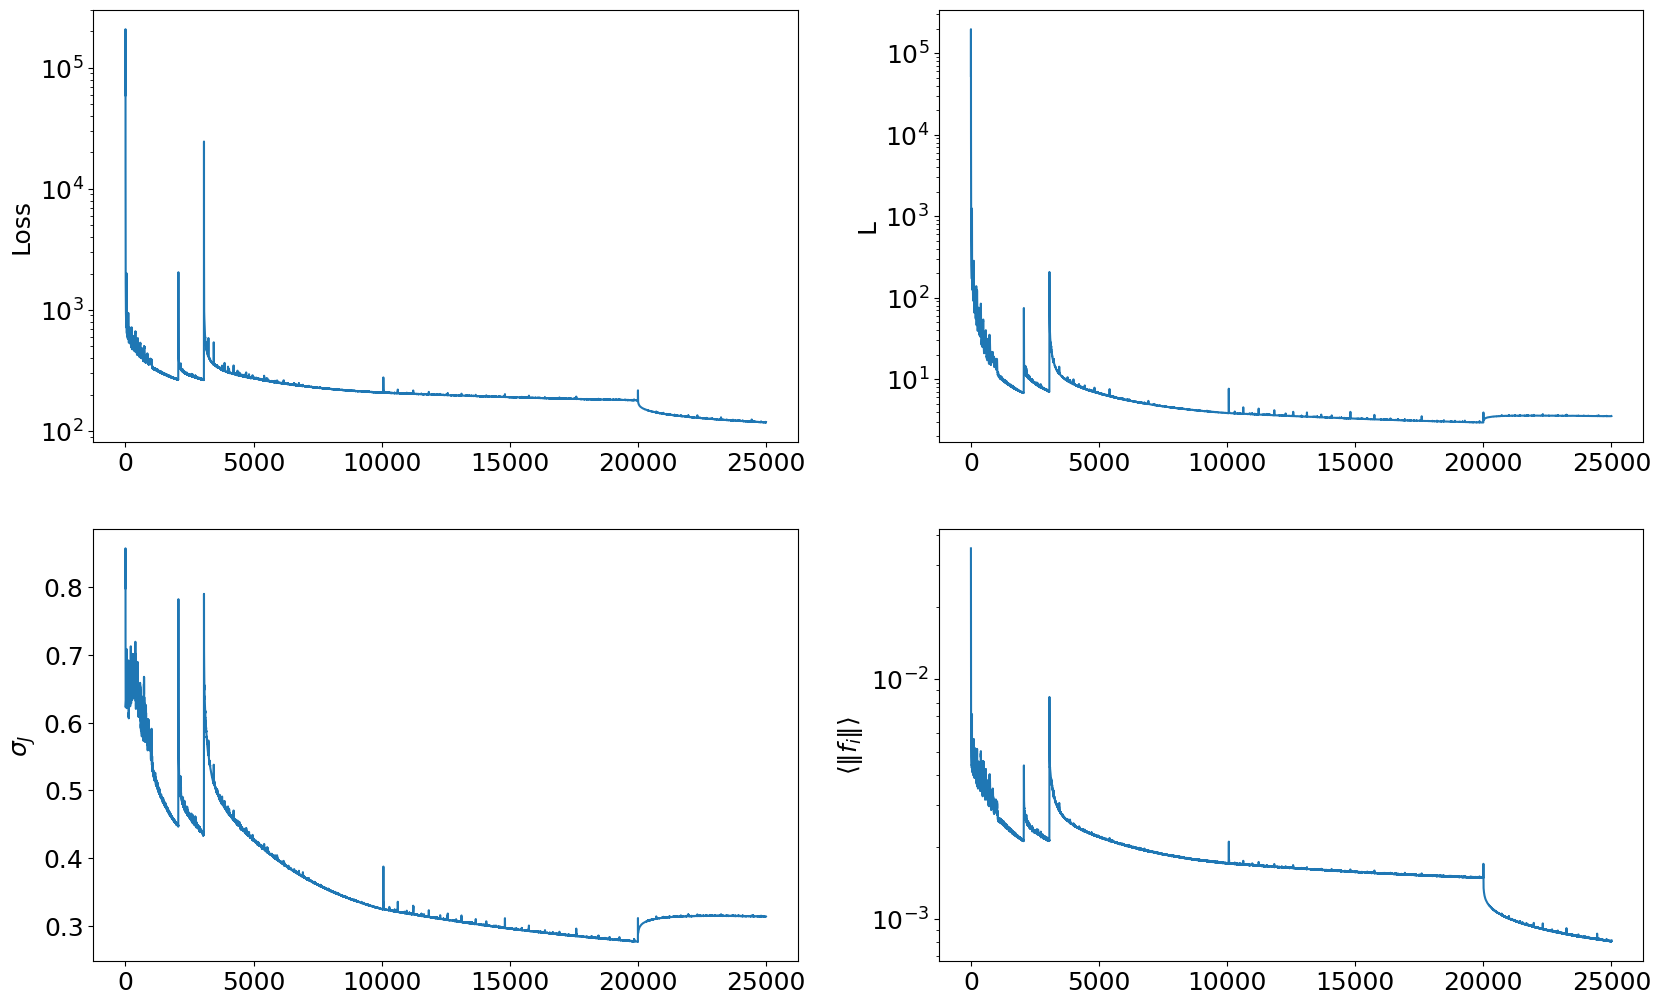

In [8]:
plt.rcParams['font.size'] = 18
plt.figure(figsize=(20,6.18*2))
plt.subplot(221)
plt.plot(model.loss_list)
plt.yscale('log')
plt.ylabel('Loss')

plt.subplot(222)
plt.plot(model.L_list)
plt.yscale('log')
plt.ylabel('L')

plt.subplot(223)
plt.plot(model.sJ_list)
plt.ylabel('$\sigma_J$')

plt.subplot(224)
plt.plot(model.fi_list)
plt.yscale('log')
plt.ylabel(r'$\left<\|f_i\|\right>$')

plt.show()

In [13]:
evaluate(nlfff_data,is_eval=False)

(0.0013745475, 0.3925422430038452, 48.589881896972656)

In [13]:
model.net.eval()
pred = model.net(torch.from_numpy(PF_data).unsqueeze(0))[0].detach().cpu().numpy()
evaluate(pred,is_eval=False)

(0.0008097161, 0.3138509690761566, 3.5283641815185547)

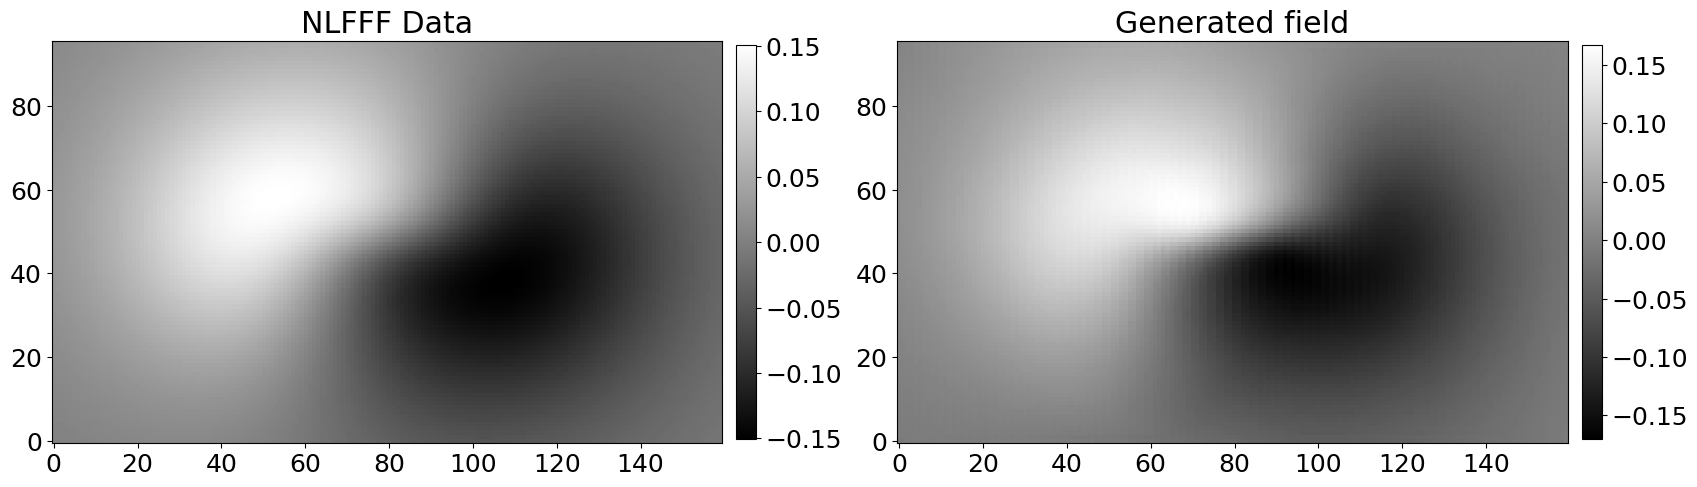

In [11]:
idir = 2
zi = 30
plt.figure(figsize=(20,6.18))
plt.subplot(121)
plt.imshow(nlfff_data[idir,:,:,zi],origin='lower',cmap='gray')
plt.title('NLFFF Data')
plt.colorbar(fraction=0.028, pad=0.02)

plt.subplot(122)
plt.imshow(pred[idir,:,:,zi],origin='lower',cmap='gray')
plt.title('Generated field')
plt.colorbar(fraction=0.028, pad=0.02)

plt.show()

In [17]:
cube_dot(nlfff_data,pred).sum()/((cube_dot(nlfff_data,nlfff_data).sum())*(cube_dot(pred,pred).sum()))**0.5

tensor(0.9716)

In [18]:
Bdotb = cube_dot(nlfff_data,pred)
Bi = cube_dot(nlfff_data,nlfff_data)**0.5
bi = cube_dot(pred,pred)**0.5
(Bdotb/(Bi*bi)).mean()

tensor(0.8579)

In [14]:
from PF2nlfff.mf_module import *
vec_corr_metric(nlfff_data,pred)

0.9716144198373917

In [16]:
CS_metric(nlfff_data,pred)

0.85785145

In [19]:
1-norm_vec_err(nlfff_data, pred)

0.7927961200475693

In [21]:
1-mean_vec_err(pred,nlfff_data)

0.6059988141059875

In [24]:
mag_e_frac(pred,nlfff_data)

1.0193181